# Hotel Cancellation — Logistic Regression

Logistic regression written in TensorFlow (a single sigmoid unit, no hidden layer), trained on the scaled 42-feature split from `feature_prep.ipynb`. This is the interpretable linear model in the project's four-model comparison.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

PROCESSED_DIR = "../data/processed"
SEED = 7

tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 2. Load Data

Already cleaned, encoded, split and scaled by `feature_prep.ipynb`. This notebook does no preprocessing of its own, so every model in the comparison sees identical inputs.

In [2]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

print("X_train:", X_train_full.shape, "  X_test:", X_test.shape)
print("Cancel rate  train:", round(Y_train_full.mean(), 4),
      "  test:", round(Y_test.mean(), 4))

X_train: (95368, 42)   X_test: (23840, 42)
Cancel rate  train: 0.3708   test: 0.3708


## 3. Train / Validation Split

A stratified 80/20 carve-out of the training set for tuning. Test stays untouched until section 6. Class weights offset the 37% / 63% imbalance.

In [3]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=SEED, stratify=Y_train_full)

weights = compute_class_weight("balanced", classes=np.unique(Y_train), y=Y_train)
class_weight = {int(c): w for c, w in zip(np.unique(Y_train), weights)}

print("Train:", X_train.shape, "  Val:", X_val.shape)
print("Class weights:", {k: round(v, 3) for k, v in class_weight.items()})

Train: (76294, 42)   Val: (19074, 42)
Class weights: {0: np.float64(0.795), 1: np.float64(1.349)}


## 4. Model

Logistic regression is one sigmoid unit trained on binary cross-entropy — mathematically the same as `sklearn`'s `LogisticRegression`, but in TensorFlow as the project requires.

In [4]:
def build_logreg(n_features, learning_rate=1e-3, l2=0.0):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(
            1, activation="sigmoid",
            kernel_regularizer=tf.keras.regularizers.l2(l2) if l2 else None),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    return model


def fit_model(model, X_tr, Y_tr, X_va, Y_va, epochs=60):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)
    model.fit(
        X_tr.to_numpy("float32"), Y_tr.to_numpy(),
        validation_data=(X_va.to_numpy("float32"), Y_va.to_numpy()),
        class_weight=class_weight,
        epochs=epochs, batch_size=512, callbacks=[early_stop], verbose=0,
    )
    return model


def scores(model, X, Y):
    probs = model.predict(X.to_numpy("float32"), verbose=0).ravel()
    return roc_auc_score(Y, probs), average_precision_score(Y, probs)

## 5. Hyperparameter Tuning

Two knobs matter for a linear model: the learning rate and the L2 penalty. Each config uses early stopping on validation PR-AUC, and the best validation PR-AUC wins.

In [5]:
results = []

for lr in [1e-3, 5e-3, 1e-2]:
    for l2 in [0.0, 1e-4, 1e-3]:
        model = fit_model(build_logreg(X_train.shape[1], lr, l2),
                          X_train, Y_train, X_val, Y_val)
        val_roc, val_pr = scores(model, X_val, Y_val)
        results.append({"learning_rate": lr, "l2": l2,
                        "val_roc_auc": round(val_roc, 4),
                        "val_pr_auc": round(val_pr, 4)})
        print(f"lr={lr:<7} l2={l2:<7} val ROC-AUC={val_roc:.4f}  val PR-AUC={val_pr:.4f}")

tuning_df = pd.DataFrame(results).sort_values("val_pr_auc", ascending=False)
tuning_df

lr=0.001   l2=0.0     val ROC-AUC=0.8842  val PR-AUC=0.8432


lr=0.001   l2=0.0001  val ROC-AUC=0.8841  val PR-AUC=0.8431


lr=0.001   l2=0.001   val ROC-AUC=0.8828  val PR-AUC=0.8421


lr=0.005   l2=0.0     val ROC-AUC=0.8847  val PR-AUC=0.8435


lr=0.005   l2=0.0001  val ROC-AUC=0.8844  val PR-AUC=0.8433


lr=0.005   l2=0.001   val ROC-AUC=0.8826  val PR-AUC=0.8419


lr=0.01    l2=0.0     val ROC-AUC=0.8845  val PR-AUC=0.8432


lr=0.01    l2=0.0001  val ROC-AUC=0.8841  val PR-AUC=0.8430


lr=0.01    l2=0.001   val ROC-AUC=0.8823  val PR-AUC=0.8416


,learning_rate,l2,val_roc_auc,val_pr_auc
3,0.005,0.0000,0.8847,0.8435
4,0.005,0.0001,0.8844,0.8433
0,0.001,0.0000,0.8842,0.8432
6,0.010,0.0000,0.8845,0.8432
1,0.001,0.0001,0.8841,0.8431
7,0.010,0.0001,0.8841,0.8430
2,0.001,0.0010,0.8828,0.8421
5,0.005,0.0010,0.8826,0.8419
8,0.010,0.0010,0.8823,0.8416


## 6. Final Evaluation

Retrain the winning config and score it once on the held-out test set.

In [6]:
best = tuning_df.iloc[0]
print("Best config  learning_rate:", best["learning_rate"], "  l2:", best["l2"])

final_model = fit_model(
    build_logreg(X_train.shape[1], float(best["learning_rate"]), float(best["l2"])),
    X_train, Y_train, X_val, Y_val)

train_roc, train_pr = scores(final_model, X_train, Y_train)
val_roc, val_pr = scores(final_model, X_val, Y_val)
test_roc, test_pr = scores(final_model, X_test, Y_test)

print(f"Train  ROC-AUC {train_roc:.4f}   PR-AUC {train_pr:.4f}")
print(f"Val    ROC-AUC {val_roc:.4f}   PR-AUC {val_pr:.4f}")
print(f"Test   ROC-AUC {test_roc:.4f}   PR-AUC {test_pr:.4f}")

Best config  learning_rate: 0.005   l2: 0.0


Train  ROC-AUC 0.8845   PR-AUC 0.8444
Val    ROC-AUC 0.8847   PR-AUC 0.8435
Test   ROC-AUC 0.8839   PR-AUC 0.8443


Accuracy:  0.7945
Precision: 0.7008
Recall:    0.7778
F1:        0.7373


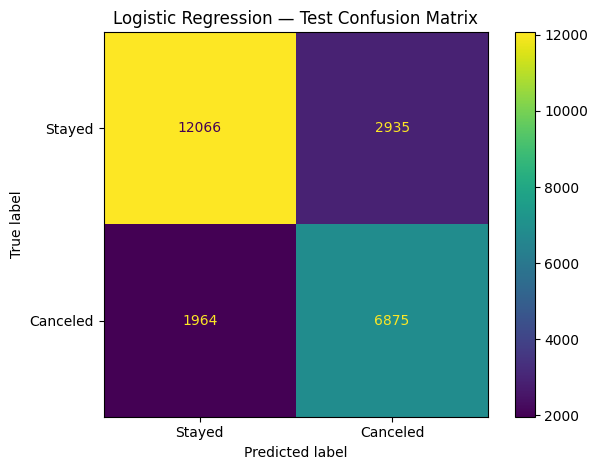

In [7]:
test_probs = final_model.predict(X_test.to_numpy("float32"), verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(Y_test, test_preds), 4))
print("Precision:", round(precision_score(Y_test, test_preds), 4))
print("Recall:   ", round(recall_score(Y_test, test_preds), 4))
print("F1:       ", round(f1_score(Y_test, test_preds), 4))

ConfusionMatrixDisplay(confusion_matrix(Y_test, test_preds),
                       display_labels=["Stayed", "Canceled"]).plot()
plt.title("Logistic Regression — Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Coefficients

What the linear model adds to the comparison: signed effects. A tree's feature importance says a feature mattered; a coefficient says in which direction. The inputs are standardized, so magnitudes are comparable across features.

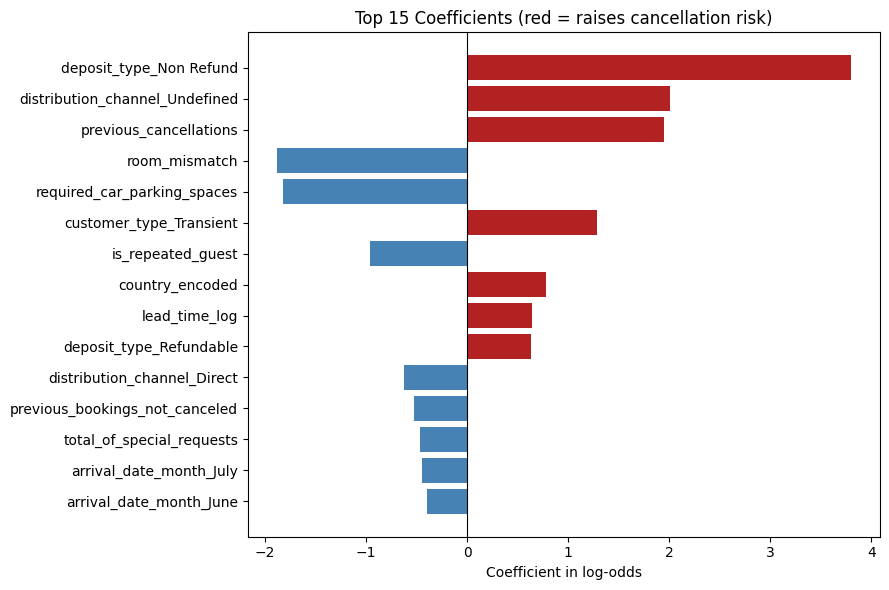

Intercept: -1.4244


In [8]:
kernel, bias = final_model.layers[0].get_weights()
coefs = pd.Series(kernel.ravel(), index=X_train.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values,
         color=["firebrick" if v > 0 else "steelblue" for v in top.values])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Coefficients (red = raises cancellation risk)")
plt.xlabel("Coefficient in log-odds")
plt.tight_layout()
plt.show()

print("Intercept:", round(float(bias[0]), 4))

## 8. Results

Best config: `learning_rate=0.005`, `l2=0.0`.

| Metric | Validation | Test |
|---|---|---|
| ROC-AUC | 0.8847 | 0.8839 |
| PR-AUC | 0.8435 | 0.8443 |

Test accuracy 0.7945, precision 0.7008, recall 0.7778, F1 0.7373.

Train and test PR-AUC land within 0.0001 of each other, so there is no overfitting to mitigate here — a linear model has no capacity to memorize rows. The tuning surface is nearly flat (0.8416 to 0.8435 across all nine configs) and L2 only ever hurt, which says the ceiling comes from the linear decision boundary itself rather than from tuning. That gap to the non-linear models is the measure of what interactions are worth on this dataset.